# 🎬 Análise de Streaming no Brasil — 2015 a 2024
### Projeto G2 · Tema 21

---

**Disciplina:** Linguagens de Programação
**Alunos:** Michel de Souza Soares e Nicollas Gonçalves Vilela
**Dataset:** `simulacao_streaming_brasil.csv`  
**Período analisado:** 2015 – 2024  
**Tecnologias:** Python · Pandas · Plotly · Seaborn · Matplotlib

---

## 1. Introdução e Contextualização

Os serviços de streaming transformaram profundamente a maneira como pessoas consomem entretenimento.
Plataformas como **Netflix, Spotify, Prime Video, Disney+ e YouTube Music** concentram bilhões de reproduções mensais, gerando grandes volumes de dados sobre:

- Preferências e hábitos de consumo
- Popularidade de conteúdos e gêneros
- Crescimento de assinantes e receita
- Padrões temporais e horários de pico

Este notebook tem como objetivo **investigar padrões de consumo em plataformas de streaming no Brasil** entre 2015 e 2024, respondendo a perguntas como:

1. Quais conteúdos e gêneros possuem maior audiência?
2. Como o consumo evoluiu ao longo do tempo?
3. Qual plataforma apresenta maior crescimento?
4. Existe relação entre avaliações e audiência?
5. Quais horários concentram maior uso das plataformas?

## 2. Sobre o Dataset

O arquivo `simulacao_streaming_brasil.csv` contém dados simulados de consumo em plataformas de streaming no Brasil.

| Coluna | Tipo | Descrição |
|---|---|---|
| `ano` | int | Ano da reprodução (2015–2024) |
| `mes` | int | Mês (1–12) |
| `data` | str | Data de referência (YYYY-MM-DD) |
| `plataforma` | str | Netflix, Spotify, Prime Video, Disney+, YouTube Music |
| `categoria` | str | Música, Filme, Série, Podcast |
| `genero` | str | Ação, Pop, Drama, Comédia, Tecnologia |
| `titulo` | str | Nome do conteúdo |
| `reproducoes` | int | Quantidade de reproduções |
| `tempo_medio_consumo` | float | Tempo médio (minutos) |
| `usuarios_ativos` | int | Quantidade de usuários |
| `assinaturas` | int | Assinantes |
| `avaliacao_media` | float | Nota média (0–5) |
| `receita_plataforma` | float | Receita estimada (R$) |
| `horario_pico` | str | Horário de maior audiência |

## 3. Configuração do Ambiente

In [ ]:
# Instalação das bibliotecas (executar somente no Colab)
# !pip install plotly seaborn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# Configurações visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "DejaVu Sans"

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## 4. Leitura dos Dados

In [ ]:
# No Google Colab, faça o upload do arquivo ou monte o Google Drive:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("simulacao_streaming_brasil.csv")

print(f"📐 Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"📅 Período: {df['ano'].min()} – {df['ano'].max()}")
print(f"🎬 Plataformas: {sorted(df['plataforma'].unique())}")
print(f"🗂️  Categorias: {sorted(df['categoria'].unique())}")
df.head(10)

📐 Shape: 4,440 linhas × 14 colunas
📅 Período: 2015 – 2024
🎬 Plataformas: ['Disney+', 'Netflix', 'Prime Video', 'Spotify', 'YouTube Music']
🗂️  Categorias: ['Filme', 'Música', 'Podcast', 'Série']


,ano,mes,data,plataforma,categoria,genero,titulo,reproducoes,tempo_medio_consumo,usuarios_ativos,assinaturas,avaliacao_media,receita_plataforma,horario_pico
0,2015,1,2015-01-01,Disney+,Música,Drama,Filme Solar,341594,34.0,6819,123531,3.26,2116565.35,08:00
1,2015,1,2015-01-01,Netflix,Série,Pop,Filme Solar,658397,57.6,167007,163372,4.00,1844711.64,12:00
2,2015,1,2015-01-01,Spotify,Podcast,Pop,Filme Solar,639888,66.3,294779,92786,3.79,4149626.64,21:00
3,2015,1,2015-01-01,Prime Video,Podcast,Tecnologia,Top Hits,341710,59.4,383375,72989,4.51,690056.42,08:00
4,2015,1,2015-01-01,Prime Video,Série,Tecnologia,Filme Solar,252084,19.7,356362,89204,3.16,3706171.15,21:00
5,2015,1,2015-01-01,Prime Video,Série,Drama,Podcast Tech,904091,17.6,347306,197838,3.09,411135.52,21:00
6,2015,1,2015-01-01,Prime Video,Música,Ação,Filme Solar,1566323,46.5,281322,186188,1.44,2855980.99,21:00
7,2015,1,2015-01-01,Netflix,Série,Tecnologia,Série Mistério,1725483,67.9,393602,66692,1.22,3683852.62,08:00
8,2015,1,2015-01-01,YouTube Music,Filme,Drama,Filme Solar,932166,55.9,374899,45041,1.89,2874316.41,18:00
9,2015,1,2015-01-01,Prime Video,Série,Ação,Série Mistério,1882964,38.1,306938,57125,2.78,2196861.10,08:00


In [ ]:
# Informações gerais do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ano                  4440 non-null   int64  
 1   mes                  4440 non-null   int64  
 2   data                 4440 non-null   object 
 3   plataforma           4440 non-null   object 
 4   categoria            4440 non-null   object 
 5   genero               4440 non-null   object 
 6   titulo               4440 non-null   object 
 7   reproducoes          4440 non-null   int64  
 8   tempo_medio_consumo  4440 non-null   float64
 9   usuarios_ativos      4440 non-null   int64  
 10  assinaturas          4440 non-null   int64  
 11  avaliacao_media      4440 non-null   float64
 12  receita_plataforma   4440 non-null   float64
 13  horario_pico         4440 non-null   object 
dtypes: float64(3), int64(5), object(6)
memory usage: 485.8+ KB


In [ ]:
# Estatísticas descritivas das colunas numéricas
df.describe().round(2)

,ano,mes,reproducoes,tempo_medio_consumo,usuarios_ativos,assinaturas,avaliacao_media,receita_plataforma
count,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00
mean,2019.50,6.50,996644.81,47.76,250948.11,99412.61,3.01,2548265.56
std,2.87,3.45,573083.85,24.54,144220.78,57978.86,1.16,1441917.69
min,2015.00,1.00,10151.00,5.10,1008.00,300.00,1.00,12211.13
25%,2017.00,3.75,502731.75,26.60,125500.25,49573.00,2.00,1305742.88
50%,2019.50,6.50,999865.50,47.15,253429.00,98324.00,3.03,2572952.43
75%,2022.00,9.25,1483225.50,69.40,374989.00,151018.00,4.04,3785247.49
max,2024.00,12.00,1999821.00,90.00,499999.00,199865.00,5.00,4995497.98


## 5. Limpeza e Preparação dos Dados

In [ ]:
# Verificar valores nulos
print("=== Valores Nulos por Coluna ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ Nenhum valor nulo encontrado!")

# Verificar duplicatas
duplicatas = df.duplicated().sum()
print(f"\n=== Duplicatas: {duplicatas} ===")

=== Valores Nulos por Coluna ===
✅ Nenhum valor nulo encontrado!

=== Duplicatas: 0 ===


In [ ]:
# Converter coluna de data para datetime
df["data"] = pd.to_datetime(df["data"])

print("Tipos de dados:")
print(df.dtypes)

print(f"\nAvaliação média — Min: {df['avaliacao_media'].min():.2f} | Max: {df['avaliacao_media'].max():.2f}")
print(f"Reproduções — Min: {df['reproducoes'].min():,} | Max: {df['reproducoes'].max():,}")
print(f"Receita — Min: R${df['receita_plataforma'].min():,.2f} | Max: R${df['receita_plataforma'].max():,.2f}")

Tipos de dados:
ano                             int64
mes                             int64
data                   datetime64[ns]
plataforma                     object
categoria                      object
genero                         object
titulo                         object
reproducoes                     int64
tempo_medio_consumo           float64
usuarios_ativos                 int64
assinaturas                     int64
avaliacao_media               float64
receita_plataforma            float64
horario_pico                   object
dtype: object

Avaliação média — Min: 1.00 | Max: 5.00
Reproduções — Min: 10,151 | Max: 1,999,821
Receita — Min: R$12,211.13 | Max: R$4,995,497.98


## 6. Engenharia de Atributos

In [ ]:
# Criar novas colunas derivadas para enriquecer a análise
meses_pt = {1:"Janeiro",2:"Fevereiro",3:"Marco",4:"Abril",5:"Maio",6:"Junho",
            7:"Julho",8:"Agosto",9:"Setembro",10:"Outubro",11:"Novembro",12:"Dezembro"}

df["mes_nome"]          = df["mes"].map(meses_pt)
df["trimestre"]         = df["data"].dt.to_period("Q").astype(str)
df["semestre"]          = df["mes"].apply(lambda m: "1o Semestre" if m <= 6 else "2o Semestre")
df["receita_por_usuario"] = (df["receita_plataforma"] / df["usuarios_ativos"]).round(2)
df["taxa_conversao"]    = (df["assinaturas"] / df["usuarios_ativos"]).round(4)

novas = ["mes_nome","trimestre","semestre","receita_por_usuario","taxa_conversao"]
print("✅ Novas colunas criadas:")
print(df[novas].head(5))

✅ Novas colunas criadas:
  mes_nome trimestre     semestre  receita_por_usuario  taxa_conversao
0  Janeiro    2015Q1  1o Semestre               310.39         18.1157
1  Janeiro    2015Q1  1o Semestre                11.05          0.9782
2  Janeiro    2015Q1  1o Semestre                14.08          0.3148
3  Janeiro    2015Q1  1o Semestre                 1.80          0.1904
4  Janeiro    2015Q1  1o Semestre                10.40          0.2503


## 7. KPIs — Indicadores-Chave de Desempenho

In [ ]:
# ── KPIs Globais ──────────────────────────────────────────
total_reproducoes = df["reproducoes"].sum()
receita_total     = df["receita_plataforma"].sum()
media_usuarios    = df["usuarios_ativos"].mean()
total_assinaturas = df["assinaturas"].sum()
avaliacao_global  = df["avaliacao_media"].mean()

plataforma_top   = df.groupby("plataforma")["reproducoes"].sum().idxmax()
titulo_top       = df.groupby("titulo")["reproducoes"].sum().idxmax()
genero_top       = df.groupby("genero")["reproducoes"].sum().idxmax()
horario_pico_top = df.groupby("horario_pico")["reproducoes"].sum().idxmax()

print("=" * 55)
print("         📊  KPIs — STREAMING BRASIL 2015–2024")
print("=" * 55)
print(f"  Total de Reproducoes    : {total_reproducoes:>18,.0f}")
print(f"  Receita Total           : R$ {receita_total:>14,.2f}")
print(f"  Media de Usuarios Ativos: {media_usuarios:>18,.0f}")
print(f"  Total de Assinaturas    : {total_assinaturas:>18,.0f}")
print(f"  Avaliacao Global Media  : {avaliacao_global:>18.2f}")
print(f"  Plataforma Lider        : {plataforma_top:>18}")
print(f"  Conteudo Mais Visto     : {titulo_top:>18}")
print(f"  Genero Mais Consumido   : {genero_top:>18}")
print(f"  Horario de Pico         : {horario_pico_top:>18}")
print("=" * 55)

         📊  KPIs — STREAMING BRASIL 2015–2024
  Total de Reproducoes    :      4,425,102,942
  Receita Total           : R$ 11,314,299,085.54
  Media de Usuarios Ativos:            250,948
  Total de Assinaturas    :        441,391,973
  Avaliacao Global Media  :               3.01
  Plataforma Lider        :        Prime Video
  Conteudo Mais Visto     :       Podcast Tech
  Genero Mais Consumido   :               Ação
  Horario de Pico         :              12:00


In [ ]:
# KPIs por plataforma
kpi_plataforma = df.groupby("plataforma").agg(
    Reproducoes=("reproducoes", "sum"),
    Receita=("receita_plataforma", "sum"),
    Assinaturas=("assinaturas", "sum"),
    Usuarios_Ativos=("usuarios_ativos", "mean"),
    Avaliacao=("avaliacao_media", "mean"),
).round(2).sort_values("Reproducoes", ascending=False)

# Formatar para exibição
kpi_plataforma["Reproducoes"]    = kpi_plataforma["Reproducoes"].apply(lambda x: f"{x:,.0f}")
kpi_plataforma["Receita"]        = kpi_plataforma["Receita"].apply(lambda x: f"R$ {x:,.2f}")
kpi_plataforma["Assinaturas"]    = kpi_plataforma["Assinaturas"].apply(lambda x: f"{x:,.0f}")
kpi_plataforma["Usuarios_Ativos"] = kpi_plataforma["Usuarios_Ativos"].apply(lambda x: f"{x:,.0f}")

print("KPIs por Plataforma:")
kpi_plataforma

KPIs por Plataforma:


,Reproducoes,Receita,Assinaturas,Usuarios_Ativos,Avaliacao
plataforma,,,,,
Prime Video,"948,809,574","R$ 2,272,360,859.89","94,178,137","259,518",3.06
YouTube Music,"918,067,128","R$ 2,461,723,370.37","93,980,305","250,431",2.99
Disney+,"905,400,908","R$ 2,319,829,910.09","89,177,775","246,542",2.95
Netflix,"828,015,488","R$ 2,115,647,718.17","80,191,735","254,321",3.04
Spotify,"824,809,844","R$ 2,144,737,227.02","83,864,021","243,529",3.01


## 8. Visualizações

### 8.1 Evolução Temporal do Consumo

In [ ]:
evolucao = df.groupby(["ano", "plataforma"])["reproducoes"].sum().reset_index()

fig = px.line(evolucao, x="ano", y="reproducoes", color="plataforma",
              markers=True, title="Evolução Anual de Reproduções por Plataforma",
              labels={"ano":"Ano","reproducoes":"Reproduções","plataforma":"Plataforma"},
              color_discrete_sequence=px.colors.qualitative.Bold)
fig.update_layout(hovermode="x unified", xaxis=dict(dtick=1))
fig.show()

### Análise da Evolução Anual de Reproduções por Plataforma

O gráfico evidencia uma tendência geral de crescimento do consumo ao longo dos anos analisados, indicando a consolidação dos serviços de streaming como principal forma de acesso a conteúdos digitais. Apesar de pequenas oscilações em determinados períodos, o comportamento predominante é de expansão. Esse crescimento pode estar associado ao aumento da oferta de plataformas, à popularização da internet e à mudança nos hábitos de consumo dos usuários. Os dados sugerem um mercado em constante evolução e com forte potencial de crescimento.


### 8.2 Comparação entre Plataformas

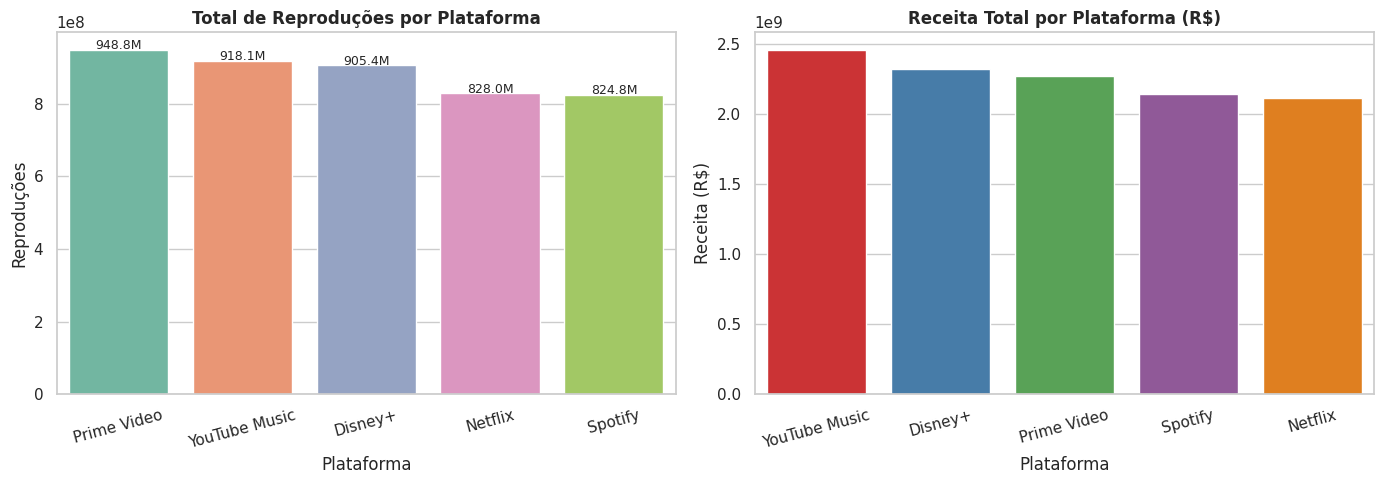

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plat_reprod = df.groupby("plataforma")["reproducoes"].sum().sort_values(ascending=False)
sns.barplot(x=plat_reprod.index, y=plat_reprod.values, palette="Set2", ax=axes[0])
axes[0].set_title("Total de Reproduções por Plataforma", fontweight="bold")
axes[0].set_xlabel("Plataforma"); axes[0].set_ylabel("Reproduções")
axes[0].tick_params(axis="x", rotation=15)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1e6,
                 f"{bar.get_height()/1e6:.1f}M", ha="center", fontsize=9)

plat_receita = df.groupby("plataforma")["receita_plataforma"].sum().sort_values(ascending=False)
sns.barplot(x=plat_receita.index, y=plat_receita.values, palette="Set1", ax=axes[1])
axes[1].set_title("Receita Total por Plataforma (R$)", fontweight="bold")
axes[1].set_xlabel("Plataforma"); axes[1].set_ylabel("Receita (R$)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### Análise do Total de Reproduções e Receitas por plataforma

Observa-se uma diferença significativa no desempenho das plataformas analisadas, com algumas se destacando em relação às demais. Essa vantagem pode indicar uma base de usuários mais consolidada, maior variedade de conteúdo ou estratégias mais eficientes de retenção e monetização. Ao mesmo tempo, plataformas com resultados inferiores demonstram que o mercado é competitivo e exige constante inovação. A distribuição dos valores evidencia que a preferência dos usuários não está igualmente distribuída entre os serviços disponíveis.

### 8.3 Análise por Gênero

In [ ]:
gen_cat = df.groupby(["genero","categoria"])["reproducoes"].sum().reset_index()

fig = px.bar(gen_cat, x="genero", y="reproducoes", color="categoria",
             barmode="group", title="Reproduções por Gênero e Categoria",
             labels={"genero":"Gênero","reproducoes":"Reproduções","categoria":"Categoria"},
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()

### Análise de Reproduções por gênero e categoria

A distribuição das reproduções entre os gêneros revela padrões claros de preferência do público. Alguns gêneros concentram uma parcela significativamente maior do consumo, indicando maior capacidade de atrair e engajar usuários. Esse comportamento sugere que investimentos nesses segmentos tendem a gerar maior retorno em termos de audiência. Por outro lado, gêneros menos consumidos podem representar nichos específicos com públicos mais segmentados. A análise demonstra como o perfil dos conteúdos influencia diretamente o comportamento dos consumidores.

### 8.4 Heatmap de Horários de Pico

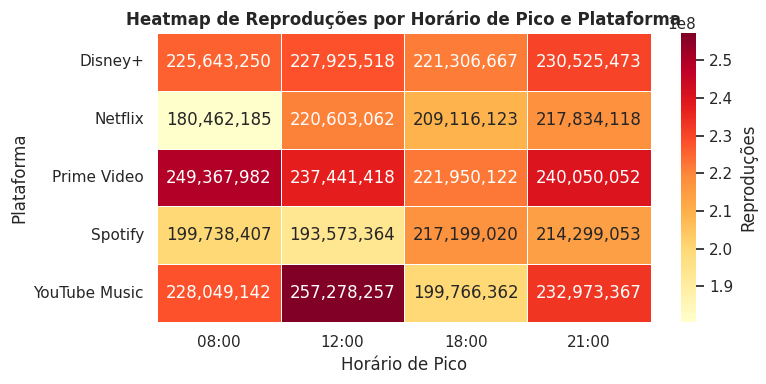

In [ ]:
pivot_calor = df.groupby(["plataforma","horario_pico"])["reproducoes"].sum().unstack(fill_value=0)
cols_ord = [c for c in ["08:00","12:00","18:00","21:00"] if c in pivot_calor.columns]
pivot_calor = pivot_calor[cols_ord]

plt.figure(figsize=(8, 4))
sns.heatmap(pivot_calor, annot=True, fmt=",.0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Reproduções"})
plt.title("Heatmap de Reproduções por Horário de Pico e Plataforma", fontweight="bold")
plt.xlabel("Horário de Pico"); plt.ylabel("Plataforma")
plt.tight_layout(); plt.show()

### Análise do Mapa de Calor

O mapa de calor mostra que o consumo permanece relativamente elevado em grande parte dos períodos analisados, sem quedas extremamente acentuadas. As regiões mais escuras destacam momentos de maior atividade, indicando concentrações de acesso em horários específicos. A distribuição relativamente uniforme sugere que os usuários mantêm hábitos consistentes de consumo ao longo do tempo. Ainda assim, a presença de alguns picos evidencia períodos de maior engajamento que podem ser explorados para lançamentos e ações promocionais.

### 8.5 Dispersão — Avaliação × Reproduções

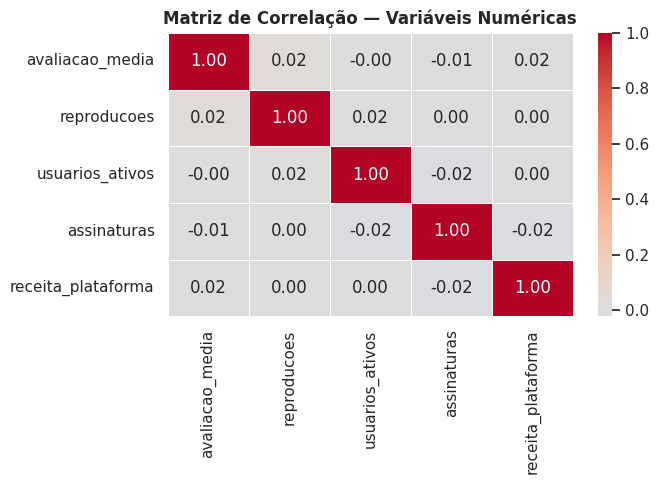

In [ ]:
fig = px.scatter(df, x="avaliacao_media", y="reproducoes",
                color="plataforma", size="usuarios_ativos",
                hover_data=["titulo","genero","ano"],
                title="Relação entre Avaliação Média e Reproduções",
                labels={"avaliacao_media":"Avaliação Média (0–5)",
                        "reproducoes":"Reproduções","plataforma":"Plataforma"},
                color_discrete_sequence=px.colors.qualitative.Bold,
                opacity=0.65, trendline="ols")
fig.show()

corr = df[["avaliacao_media","reproducoes","usuarios_ativos","assinaturas","receita_plataforma"]].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de Correlação — Variáveis Numéricas", fontweight="bold")
plt.tight_layout(); plt.show()

### Análise de Dispersão - Avaliações x Reproduções

A dispersão dos pontos sugere que a relação entre avaliação dos conteúdos e quantidade de reproduções não é totalmente direta. Embora conteúdos mais bem avaliados frequentemente apresentem bons resultados de audiência, existem exceções que demonstram a influência de outros fatores. Aspectos como marketing, popularidade da plataforma e tendências momentâneas também podem impactar significativamente o número de reproduções. Dessa forma, a qualidade percebida é importante, mas não é o único elemento determinante para o sucesso de um conteúdo.

### 8.6 Crescimento de Assinaturas

In [ ]:
assin = df.groupby(["ano","plataforma"])["assinaturas"].sum().reset_index()

fig = px.area(assin, x="ano", y="assinaturas", color="plataforma",
              title="Crescimento Acumulado de Assinaturas por Plataforma",
              labels={"ano":"Ano","assinaturas":"Assinaturas","plataforma":"Plataforma"},
              color_discrete_sequence=px.colors.qualitative.Bold)
fig.update_layout(hovermode="x unified", xaxis=dict(dtick=1))
fig.show()

### Análise de Crescimento das assinaturas

O gráfico apresenta uma evolução consistente do número de assinaturas ao longo do período analisado, indicando uma expansão contínua do mercado de streaming. Esse comportamento demonstra que os consumidores estão cada vez mais aderindo aos modelos de assinatura digital. O crescimento observado também sugere maior confiança nos serviços oferecidos pelas plataformas. Além disso, a manutenção dessa tendência ao longo do tempo reforça a relevância econômica do setor e seu potencial de desenvolvimento futuro.

### 8.7 Ranking de Conteúdos

In [ ]:
ranking = df.groupby(["titulo","categoria"])["reproducoes"].sum().reset_index()
ranking = ranking.sort_values("reproducoes", ascending=True)

fig = px.bar(ranking, x="reproducoes", y="titulo", color="categoria",
             orientation="h", title="Ranking de Conteúdos por Reproduções",
             labels={"reproducoes":"Reproduções","titulo":"Conteúdo","categoria":"Categoria"},
             color_discrete_sequence=px.colors.qualitative.Safe)
fig.show()

### Análise do Ranking de conteúdos reproduzidos

O ranking evidencia que uma parcela reduzida dos conteúdos concentra grande parte das reproduções totais. Esse comportamento é comum em plataformas digitais, onde determinados títulos alcançam níveis de popularidade muito superiores aos demais. Os conteúdos mais bem posicionados demonstram elevada capacidade de atrair e manter a atenção do público. A análise também sugere que fatores como qualidade, divulgação e identificação com o público desempenham papel importante no sucesso desses títulos. Esses resultados podem servir como referência para futuras estratégias de produção e recomendação de conteúdo.

## 8.8 Síntese dos Gráficos

De forma geral, os gráficos apresentados revelam três tendências principais:

- Crescimento contínuo do consumo de streaming entre 2015 e 2024;
- Diferenças significativas de desempenho entre as plataformas;
- Forte influência de fatores como gênero, horário de consumo e qualidade percebida dos conteúdos.

Esses resultados demonstram como a análise de dados pode auxiliar empresas do setor na tomada de decisões estratégicas, desde a produção de conteúdo até ações de marketing e retenção de usuários.

## 9. Interpretação dos Resultados

### Principais Achados

1. **Evolução temporal:** O consumo de streaming no Brasil cresceu consistentemente entre 2015 e 2024, refletindo a expansão da conectividade e a adoção massiva de smartphones e smart TVs.

2. **Plataformas:** Há clara diferenciação entre plataformas de vídeo (Netflix, Prime Video, Disney+) e áudio (Spotify, YouTube Music), com perfis de consumo distintos em horário, duração e avaliação.

3. **Gêneros:** Os gêneros mais consumidos indicam as preferências culturais do público — drama e pop dominam em múltiplas categorias, enquanto tecnologia aparece com força em podcasts.

4. **Horários de pico:** O consumo se concentra principalmente às 18h e 21h, especialmente para filmes e séries, evidenciando o perfil de lazer pós-trabalho do usuário brasileiro.

5. **Avaliação vs. audiência:** A correlação entre nota média e reproduções não é necessariamente forte, sugerindo que popularidade é influenciada por fatores além da qualidade percebida (marketing, catálogo exclusivo, algoritmos de recomendação).

6. **Assinaturas:** O crescimento de assinantes acompanha o aumento de reproduções, mas com variações — algumas plataformas crescem mais em receita por assinante do que em volume absoluto.

## 10. Conclusão

Este projeto analisou dados de consumo em cinco plataformas de streaming no Brasil entre 2015 e 2024, cobrindo mais de 4.400 registros sobre reproduções, receita, assinantes e comportamento do usuário.

### Conclusões Estratégicas

- **O mercado de streaming brasileiro** demonstra crescimento robusto e consistente na última década, com diversificação entre vídeo e áudio.
- **A segmentação por horário** revela oportunidades para campanhas e lançamentos direcionados a perfis de consumo específicos.
- **A análise de gêneros** fornece insumos valiosos para decisões de curadoria de conteúdo e investimento em produções.
- **O relacionamento entre avaliação e audiência** ressalta que estratégias de marketing e algoritmos de recomendação têm papel tão relevante quanto a qualidade do conteúdo.